In [2]:
%reload_ext autoreload
%autoreload 2

from rsg_cat import get_filters, map_columns, save_photfiles
import numpy as np
import glob, os
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.stats import sigma_clipped_stats as scs
from astropy import wcs
%matplotlib inline

### Read photometry

In [5]:
data_dir = 'data/dolphot/ngc5643_phot'
photfiles = sorted(glob.glob(os.path.join(data_dir, '*.phot')))

In [6]:
photfiles

['data/dolphot/ngc5643_phot/ngc5643_0_0.phot',
 'data/dolphot/ngc5643_phot/ngc5643_0_1.phot',
 'data/dolphot/ngc5643_phot/ngc5643_0_2.phot',
 'data/dolphot/ngc5643_phot/ngc5643_0_3.phot',
 'data/dolphot/ngc5643_phot/ngc5643_0_4.phot',
 'data/dolphot/ngc5643_phot/ngc5643_1_0.phot']

In [9]:
file = photfiles[0]
colfile = file.replace('.phot', '.phot.columns')
col_idx, filters, filt_idx = map_columns(colfile)

In [10]:
col_idx

{'X': 2,
 'Y': 3,
 'SNR': 5,
 'Sharpness': 6,
 'Crowding': 9,
 'Type': 10,
 'F090W_mag': 16,
 'F115W_mag': 29,
 'F150W_mag': 42,
 'F164N_mag': 55,
 'F187N_mag': 68,
 'F200W_mag': 81,
 'F212N_mag': 94,
 'F277W_mag': 107,
 'F356W_mag': 120,
 'F090W_err': 18,
 'F115W_err': 31,
 'F150W_err': 44,
 'F164N_err': 57,
 'F187N_err': 70,
 'F200W_err': 83,
 'F212N_err': 96,
 'F277W_err': 109,
 'F356W_err': 122}

In [12]:
save_photfiles(data_dir, outdir=os.path.join(data_dir, 'proc'))

8it [02:07, 15.98s/it]
5it [03:01, 36.36s/it]
5it [02:06, 25.36s/it]
4it [01:14, 18.67s/it]
4it [02:22, 35.51s/it]
5it [00:24,  4.80s/it]


In [38]:
df = pd.read_csv(os.path.join(data_dir, 'proc/ngc5643_0_0.csv'), header = None)
df

,0,1,2,3,4,5,6,7,8,9,...,561,562,563,564,565,566,567,568,569,570
0,1,1,3994.46,3120.46,2.78,1852.5,0.012,0.017,70,0.061,...,3.530000e-07,17.849,99.999,0.001,2.01,746.7,0.092,0.004,0.055,12
1,1,1,755.81,2647.01,2.06,1652.8,0.038,0.014,80,0.005,...,3.390000e-07,18.076,99.999,0.002,1.05,629.9,0.038,0.004,0.007,12
2,1,1,472.39,3760.62,1.54,1909.0,0.003,0.005,65,0.003,...,3.090000e-07,18.203,99.999,0.002,0.58,614.1,-0.041,-0.002,0.005,10
3,1,1,1986.83,1069.32,0.88,1735.8,-0.033,0.006,175,0.051,...,2.870000e-07,18.243,99.999,0.002,0.97,637.5,0.034,0.008,0.041,10
4,1,1,737.80,2379.47,2.57,1946.1,0.067,0.017,120,0.000,...,3.230000e-07,18.057,99.999,0.002,1.86,672.2,0.140,0.002,0.000,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45295,1,1,1517.08,1507.21,0.99,18.4,-0.027,0.230,100,0.271,...,3.870000e-09,28.660,99.999,0.336,1.15,3.2,-0.202,-0.136,0.861,0
45296,1,1,1676.32,1921.50,0.89,18.3,0.041,0.302,80,0.149,...,3.920000e-09,28.049,99.999,0.195,0.97,5.6,-0.047,-0.230,0.193,0
45297,1,1,2155.24,3153.41,0.89,11.5,0.062,0.120,25,0.109,...,3.790000e-09,28.191,99.999,0.214,1.02,5.1,0.038,-0.093,0.083,0
45298,1,1,82.22,1120.68,0.84,17.3,0.009,0.309,10,0.070,...,3.760000e-09,28.948,99.999,0.427,0.74,2.5,-0.156,0.462,0.272,0


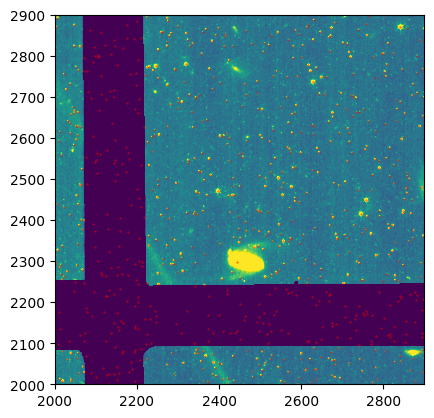

In [61]:
refim = fits.getdata(os.path.join(data_dir, 'coadd_1_0_f150w_i2d.fits'))
me, md, std = scs(refim)
plt.imshow(refim, vmin = me - 3*std, vmax = me+3*std, origin = 'lower')
plt.scatter(df[col_idx['X']], df[col_idx['Y']], s= 0.1, color = 'red')
plt.xlim(2000, 2900)
plt.ylim(2000, 2900)
plt.show()

In [69]:
col, mag =[], []
for clf in tqdm(glob.glob(os.path.join(data_dir, 'proc/*csv'))):
    try:
        _df = pd.read_csv(clf, header = None)
        f150_mag, f277_mag = _df[col_idx['F090W_mag']], _df[col_idx['F150W_mag']]
        col.extend(f150_mag-f277_mag)
        mag.extend(f277_mag)
    except:
        pass

100%|██████████| 5/5 [00:02<00:00,  2.27it/s]


In [74]:
f090_mag, f150_mag, f277_mag =[], [], []
for clf in tqdm(glob.glob(os.path.join(data_dir, 'proc/*csv'))):
    try:
        _df = pd.read_csv(clf, header = None)
        f090_mag.extend(_df[col_idx['F090W_mag']])
        f150_mag.extend(_df[col_idx['F150W_mag']])
        f277_mag.extend(_df[col_idx['F277W_mag']])
    except:
        pass

100%|██████████| 5/5 [00:02<00:00,  2.25it/s]


In [78]:
mags = np.vstack([f090_mag, f150_mag, f277_mag])

In [79]:
np.savetxt('ngc5643_mags.txt', mags)

In [73]:
fig, ax = plt.subplots(1, 1, figsize = (12, 8), dpi = 1000)
f1, f2 = 'F090W', 'F150W'

hist = ax.hist2d(col, mag, bins = 5000, norm = 'log', cmap = 'inferno')
cbar = fig.colorbar(hist[3], ax = ax, pad = 0.009)
ax.set_xlabel(rf'$m({f1}) - m({f2})$', fontsize = 32)
ax.set_ylabel(rf'$m({f2})$', fontsize = 32)
ax.set_title('NGC5643 CMD', fontsize = 32)

# ax.legend(loc = 'lower right', fontsize = 25, framealpha = 0)
ax.tick_params(axis='both', which='major', labelsize=27)
ax.tick_params(axis='both', which='minor', labelsize=27)
cbar.ax.tick_params(labelsize=27) 
ax.grid(alpha = 0.3, linestyle = '--')
ax.set_xlim(-1, 2)
ax.set_ylim(31, 19)
plt.show()

### Index photometry

In [3]:
data_dir = 'data/dolphot/ngc1365/phot'
photfiles = sorted(glob.glob(os.path.join(data_dir, '*.phot')))
refimgs = sorted(glob.glob(os.path.join(data_dir, '*i2d.fits')))

In [5]:
file = photfiles[0]
gid = '_'.join(os.path.basename(file).split('.phot')[0].split('_')[1:])
refimg = refimgs[0]
refwcs = wcs.WCS(fits.open(refimg)[1].header)
colfile = file.replace('.phot', '.phot.columns')
col_idx, filters, filt_idx = map_columns(colfile)

Set DATE-AVG to '2024-05-22T12:53:45.659' from MJD-AVG.
Set DATE-END to '2024-12-08T21:27:13.166' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -17.312168 from OBSGEO-[XYZ].
Set OBSGEO-H to 1464681009.306 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [85]:
photdf = pd.read_csv(file, sep = r'\s+', memory_map = True, 
                     header = None, iterator = True, chunksize = 100000)

In [86]:
for j, _df in tqdm(enumerate(photdf)):
    #apply cuts
    cuts = (_df[col_idx['SNR']] >= 5) & \
            ((_df[col_idx['Sharpness']])**2 <= 0.04) & \
            (_df[col_idx['Crowding']] <= 1.5) & \
            (_df[col_idx['Type']] <= 2)
    _df = _df[cuts]
    _df = _df[list(col_idx.values())]
    _df.columns = list(col_idx.keys())
    _ra, _dec = refwcs.all_pix2world(_df['X'], _df['Y'], 0)
    _df['RA'] = _ra
    _df['Dec'] = _dec
    _df['gid'] = gid
    _df['id'] = np.array(_df.index)
    _df.to_csv(f"{data_dir}/{os.path.basename(file).split('.')[0]}_{j}.csv", mode = 'a', header = True, index = False)

8it [01:21, 10.16s/it]


In [89]:
cat = None
for fl in sorted(glob.glob(os.path.join(data_dir, '*csv'))):
    if cat is None:
        cat = pd.read_csv(fl)
    else:
        df_ = pd.read_csv(fl)
        cat = pd.concat([cat, df_])
cat.reset_index(inplace=True)